In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import missingno as msno
import os

In [2]:
SHAPEFILE_PATH = "C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10/gadm41_IDN_1.shp" 
OUTPUT_DIR = "C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10" 
DATA_CSV_PATH = "C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10/Data.xlsx"
#df = pd.read_excel("C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10/Data.xlsx")

In [3]:
# Membuat folder output jika belum ada
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Folder '{OUTPUT_DIR}' telah dibuat.")



In [4]:
# --- 1. Memuat dan Membersihkan Data ---
try:
    df = pd.read_excel(DATA_CSV_PATH)
    print("Dataset CSV berhasil dimuat.")
except FileNotFoundError:
    print(f"Error: File '{DATA_CSV_PATH}' tidak ditemukan.")
    exit()
except Exception as e:
    print(f"Error saat memuat CSV: {e}")
    exit()

# Membersihkan nama kolom
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '', regex=False)

# Kolom yang perlu dibersihkan (koma -> titik untuk desimal)
cols_to_clean_decimal = [
    'Laju_pertumbuhan_PDB_perkapita',
    'Tingkat_pengganguran',
    'Tingkat_setengah_pengangguran',
    'Proporsi_kerja_informal',
    'Usia_muda_neet'
]

for col in cols_to_clean_decimal:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n--- Info Data Setelah Pembersihan ---")
df.info()

# Mengidentifikasi kolom
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
label_col = 'Provinsi'

Dataset CSV berhasil dimuat.

--- Info Data Setelah Pembersihan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Provinsi                        34 non-null     object 
 1   PDB_perkapita                   34 non-null     float64
 2   Laju_pertumbuhan_PDB_perkapita  34 non-null     float64
 3   Upah_ratarata_perjam            34 non-null     float64
 4   Tingkat_pengganguran            34 non-null     float64
 5   Tingkat_setengah_pengangguran   34 non-null     float64
 6   Proporsi_kerja_informal         34 non-null     float64
 7   Usia_muda_neet                  34 non-null     float64
dtypes: float64(7), object(1)
memory usage: 2.3+ KB


In [5]:
# --- 2. Analisis Missing Value dengan Plot Biasa ---
print("\n--- Analisis Missing Value ---")
missing_summary = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase Missing (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_summary[missing_summary['Jumlah Missing'] > 0])

# Plot Matriks
print("\nMembuat Plot Matriks Missing Value...")
fig_matrix = msno.matrix(df, figsize=(10,6), sparkline=False)
fig_matrix.get_figure().suptitle('Matriks Missing Value per Variabel')
missing_matrix_path = os.path.join(OUTPUT_DIR, 'missing_value_matrix.png')
plt.savefig(missing_matrix_path)
plt.close()
print(f"Plot matriks disimpan di: {missing_matrix_path}")



--- Analisis Missing Value ---
Empty DataFrame
Columns: [Jumlah Missing, Persentase Missing (%)]
Index: []

Membuat Plot Matriks Missing Value...
Plot matriks disimpan di: C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10\missing_value_matrix.png


In [6]:
# Plot Bar
print("Membuat Plot Bar Missing Value...")
fig_bar = msno.bar(df, figsize=(10,6))
fig_bar.get_figure().suptitle('Jumlah Data Non-Null per Variabel')
missing_bar_path = os.path.join(OUTPUT_DIR, 'missing_value_bar.png')
plt.savefig(missing_bar_path)
plt.close()
print(f"Plot bar disimpan di: {missing_bar_path}")

Membuat Plot Bar Missing Value...
Plot bar disimpan di: C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10\missing_value_bar.png


In [7]:
# Plot Heatmap
print("Membuat Plot Heatmap Korelasi Missing Value...")
if df.isnull().any().sum() > 1:
    fig_heatmap = msno.heatmap(df, figsize=(10,8))
    fig_heatmap.get_figure().suptitle('Heatmap Korelasi Missing Value')
    missing_heatmap_path = os.path.join(OUTPUT_DIR, 'missing_value_heatmap.png')
    plt.savefig(missing_heatmap_path)
    plt.close()
    print(f"Plot heatmap disimpan di: {missing_heatmap_path}")
else:
    print("Tidak cukup variabel dengan missing values untuk heatmap.")

Membuat Plot Heatmap Korelasi Missing Value...
Tidak cukup variabel dengan missing values untuk heatmap.


In [8]:
# --- 3. Visualisasi Distribusi Variabel ---
print("\n--- Visualisasi Distribusi Variabel Numerik ---")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Variabel: {col}')
    dist_plot_path = os.path.join(OUTPUT_DIR, f'distribusi_{col}.png')
    plt.savefig(dist_plot_path)
    plt.close()
    print(f"Plot distribusi '{col}' disimpan.")


--- Visualisasi Distribusi Variabel Numerik ---
Plot distribusi 'PDB_perkapita' disimpan.
Plot distribusi 'Laju_pertumbuhan_PDB_perkapita' disimpan.
Plot distribusi 'Upah_ratarata_perjam' disimpan.
Plot distribusi 'Tingkat_pengganguran' disimpan.
Plot distribusi 'Tingkat_setengah_pengangguran' disimpan.
Plot distribusi 'Proporsi_kerja_informal' disimpan.
Plot distribusi 'Usia_muda_neet' disimpan.


In [11]:
# --- 4. Visualisasi Peta Tematik ---
print("\n--- Visualisasi Peta Tematik ---")
try:
    gdf = gpd.read_file(SHAPEFILE_PATH)
    shapefile_prov_col = 'NAME_1' # Sesuaikan jika perlu

    if shapefile_prov_col not in gdf.columns:
        print(f"Error: Kolom '{shapefile_prov_col}' tidak ada di shapefile.")
        gdf = None
    else:
        df[label_col] = df[label_col].str.lower().str.strip()
        gdf[shapefile_prov_col] = gdf[shapefile_prov_col].str.lower().str.strip()
        merged_gdf = gdf.merge(df, left_on=shapefile_prov_col, right_on=label_col, how='left')

        for col in numerical_cols:
            if col in merged_gdf.columns and not merged_gdf[col].isnull().all():
                fig, ax = plt.subplots(1, 1, figsize=(12, 12))
                merged_gdf.plot(column=col, ax=ax, legend=True,
                                legend_kwds={'label': col, 'orientation': "horizontal"},
                                missing_kwds={'color': 'lightgrey', 'label': 'Data Tidak Tersedia'})
                ax.set_title(f'Peta Tematik: {col} per Provinsi')
                ax.set_axis_off()
                map_plot_path = os.path.join(OUTPUT_DIR, f'peta_tematik_{col}.png')
                plt.savefig(map_plot_path)
                plt.close()
                print(f"Peta tematik '{col}' disimpan.")
            else:
                print(f"Peta untuk '{col}' dilewati (tidak ada data).")

SyntaxError: incomplete input (2476033759.py, line 28)

In [ ]:
except Exception as e:
    print(f"Error saat memproses shapefile: {e}")
    print("Peta tematik tidak dapat dibuat.")

print("\n--- Proses Selesai ---")
print(f"Output disimpan di folder: '{OUTPUT_DIR}'")

Versi pyproj: 3.7.1
Versi geopandas: 1.0.1



--- Info Data Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Provinsi                        34 non-null     object 
 1   PDB_perkapita                   34 non-null     float64
 2   Laju_pertumbuhan_PDB_perkapita  34 non-null     object 
 3   Upah_ratarata_perjam            34 non-null     float64
 4   Tingkat_pengganguran            34 non-null     object 
 5   Tingkat_setengah_pengangguran   34 non-null     object 
 6   Proporsi_kerja_informal         34 non-null     object 
 7   Usia_muda_neet                  34 non-null     object 
dtypes: float64(2), object(6)
memory usage: 2.3+ KB

--- Info Data Setelah Pembersihan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  -----

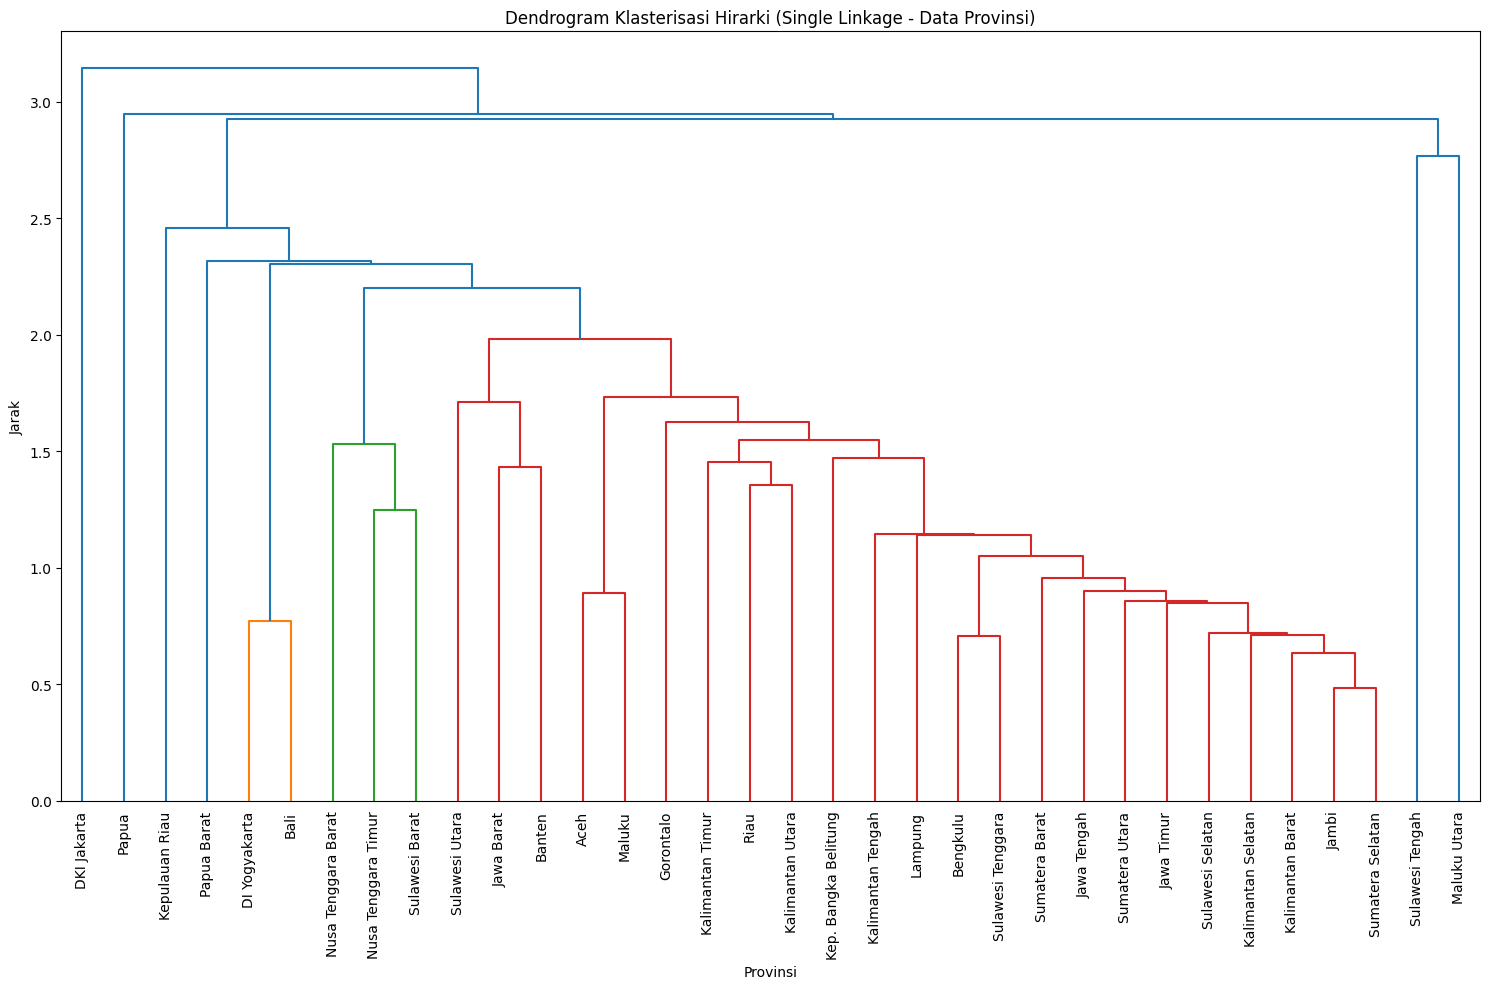

In [ ]:
# 2. Pra-pemrosesan Data (Termasuk Perbaikan Koma Desimal)
print("\n--- Info Data Awal ---")
df.info()

# Kolom yang perlu dibersihkan (koma -> titik)
cols_to_clean = [
    'Laju_pertumbuhan_PDB_perkapita',
    'Tingkat_pengganguran',
    'Tingkat_setengah_pengangguran',
    'Proporsi_kerja_informal',
    'Usia_muda_neet'
]

# Membersihkan kolom
for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n--- Info Data Setelah Pembersihan ---")
df.info()

# Memilih kolom numerik
df_numeric = df.select_dtypes(include=['float64', 'int64'])
if 'No' in df_numeric.columns:
    df_numeric = df_numeric.drop('No', axis=1)

print("\n--- Kolom Numerik Terpilih ---")
print(df_numeric.columns)
print(f"\nJumlah kolom numerik: {len(df_numeric.columns)}")

# Menangani nilai yang hilang & mengambil label
df_cleaned = df.dropna(subset=df_numeric.columns).copy()
df_numeric_cleaned = df_cleaned[df_numeric.columns]
labels = df_cleaned['Provinsi'].values

print(f"\nUkuran data setelah menghapus NaN: {df_numeric_cleaned.shape}")

# Standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric_cleaned)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_numeric_cleaned.columns, index=df_numeric_cleaned.index)

print("\n--- Data Setelah Standardisasi (Head) ---")
print(X_scaled_df.head())

# 3. Melakukan Klasterisasi Hirarki (Single Linkage)
print("\n--- Melakukan Klasterisasi Hirarki ---")
single_linkage = linkage(X_scaled_df, method='single', metric='euclidean')

# 4. Visualisasi dengan Dendrogram
print("\n--- Membuat Dendrogram ---")
plt.figure(figsize=(15, 10))
plt.title("Dendrogram Klasterisasi Hirarki (Single Linkage - Data Provinsi)")
plt.xlabel("Provinsi")
plt.ylabel("Jarak")

dendrogram(
    single_linkage,
    labels=labels,
    leaf_rotation=90.,
    leaf_font_size=10.,
)
plt.tight_layout()
plt.savefig("dendrogram_data_xlsx_fixed.png")
print("\nDendrogram dibuat dan disimpan sebagai dendrogram_data_xlsx_fixed.png.")

Error saat memuat CSV: name 'DATA_CSV_PATH' is not defined

--- Info Data Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Provinsi                        34 non-null     object 
 1   PDB_perkapita                   34 non-null     float64
 2   Laju_pertumbuhan_PDB_perkapita  34 non-null     float64
 3   Upah_ratarata_perjam            34 non-null     float64
 4   Tingkat_pengganguran            34 non-null     float64
 5   Tingkat_setengah_pengangguran   34 non-null     float64
 6   Proporsi_kerja_informal         34 non-null     float64
 7   Usia_muda_neet                  34 non-null     float64
dtypes: float64(7), object(1)
memory usage: 2.3+ KB

--- Data Awal (Head) ---
         Provinsi  PDB_perkapita  Laju_pertumbuhan_PDB_perkapita  \
0            Aceh         39.156                           


--- Analisis Missing Value ---
Empty DataFrame
Columns: [Jumlah Missing, Persentase Missing (%)]
Index: []

Menampilkan Plot Matriks Missing Value...
Plot matriks missing value disimpan di: C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10\missing_value_matrix.png

Menampilkan Plot Bar Missing Value...
Plot bar missing value disimpan di: C:/Uner/Semester 4/Data Mining I/Week 11/Tugas Kelompok 10\missing_value_bar.png

Menampilkan Plot Heatmap Korelasi Missing Value...
Tidak cukup variabel dengan missing values untuk membuat heatmap korelasi.


: 